<a href="https://colab.research.google.com/github/mostafaelhussien/hands-on-machine-learning/blob/main/Chapter_2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 01
A-Look at the Big Picture

The book says: "Welcome to Machine Learning Housing Corporation! Your task is to use California census data to build a model of housing prices in the state. This data includes metrics such as the population, median income, and median housing price for each block group in California."

The book then asks five essential questions before writing any code:
1. What exactly is the business objective?
2. What is the current solution (if any)?
3. How should you frame this problem (supervised/unsupervised, classification/regression)?
4. How should performance be measured?
5. Is this performance measure aligned with the business objective?

B-🗂️ Framing the Problem — The Decision Tree

Q1
Do we have labeled training examples?
We have a dataset where each row has the actual price (label). YES →
SUPERVISED LEARNING
. If we had no prices, we'd need unsupervised learning (find patterns without answers).

Q2
Are we predicting a number or a category?
We predict a house price in dollars (a continuous number). →
REGRESSION
. If we predicted "cheap / medium / expensive" it would be Classification. If predicting multiple values at once → multiple regression.

Q3
Does the data flow in continuously or arrive all at once?
We receive the full California census dataset at once. →
BATCH LEARNING
. If new district data arrived every hour and the model needed to update → online learning.

C-The book defines "multiple" regression as using multiple features to predict one value. "Univariate" means one output variable. This is the most common type of ML problem in industry.

Univariate Regression = نموذج يستخدم متغير واحد فقط للتنبؤ بالسعر.
مثال: سعر البيت = f(متوسط الدخل فقط)
Multiple Regression = نموذج يستخدم عدة متغيرات مع بعض للتنبؤ بالسعر.
مثال: سعر البيت = f(متوسط الدخل + الموقع + عدد الغرف + قرب البحر + ...)

D-The book says checking assumptions is not optional. Many ML projects fail not because the algorithm was bad, but because they solved the wrong problem. Spending 3 months building a regression model only to discover the system needed a classifier is a real and common mistake in industry.

Section 1 Summary
Always define the business objective first — what decision will the model output feed into?

This is a Supervised, Multiple Regression, Batch Learning problem
Supervised = we have labeled answers.
Regression = predicting a number.
Batch = train on all data at once
Check assumptions with the downstream team before spending any time building

Section 02

**Performance Measures — RMSE and MAE**

-**RMSE**:

Formula	√( mean( (pred-actual)² ) )

Outlier sensitivity	HIGH — big errors are punished extra


When to use	When large errors are especially bad and should be avoided (house prices, medical dosages)

Typical value	Always ≥ MAE for the same dataset

Main Metric in this Chapter

RMSE = √( (1/n) × Σ(predicted − actual)² )

**-MAE:**

Formula	mean( |pred-actual| )

Outlier sensitivity	LOW — all errors treated equally

When to use	When your dataset has many outliers that shouldn't dominate
the score(house prices, medical dosages)

Typical value	Always ≤ RMSE for the same dataset

Mentioned in this Chapter but not used

MAE = (1/n) × Σ|predicted − actual|

Section 03

Get the Data

The book recommends writing a download function rather than downloading manually, because:

 (1) it's reproducible — anyone can run the code and get the same data,

  (2) it can be automated to refresh data,
  
   (3) it handles the download only if needed (no re-downloading).



In [1]:
from pathlib import Path
import urllib.request
import tarfile
import pandas as pd

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")

    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
print(f"✅ Loaded! Shape: {housing.shape}")

✅ Loaded! Shape: (20640, 10)


/tmp/ipykernel_13262/3330769807.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


01

from pathlib import Path

pathlib is Python's modern way to work with file paths. Path is a class that creates smart path objects. Instead of writing paths as plain strings like "datasets/housing.tgz", we use Path("datasets/housing.tgz") which gives us useful methods like .is_file(), .mkdir(), and .exists().

🧒 Think of Path like a GPS address for a file. A plain string is just text — "23 Main Street". A Path object is a smart address that can tell you "does this place exist?", "how do I get there?", "make this folder".

02

tarball_path = Path("datasets/housing.tgz")

Creates a Path object pointing to the file housing.tgz inside the datasets folder. The .tgz extension means "tar gzip" — a compressed archive (like .zip on Linux/Mac). The file doesn't exist yet at this point — we're just creating the address for where we WILL save it.

03

if not tarball_path.is_file():

tarball_path.is_file() = Returns True if the file physically exists on disk, False if not. if not = "if the file does NOT exist, then run the download code." This smart check prevents re-downloading every time you run the code.

🧒 Like checking the fridge before going shopping: "If there is NO milk in the fridge → go buy milk. If there IS milk → skip the shop." The is_file() is "is there milk?"

04

Path("datasets").mkdir(parents=True, exist_ok=True)

mkdir() = "Make Directory" = create a folder. parents=True = If the folder needs parent folders that don't exist, create them too (e.g., if "datasets/california/housing" doesn't exist, create all three folders). exist_ok=True = If the folder already exists, don't crash — just skip silently.

05

urllib.request.urlretrieve(url, tarball_path)

urllib.request = Python's built-in URL/internet module. urlretrieve(url, destination) = Download the file from url and save it at destination. This is a blocking call — Python waits until the download is complete before moving on. In Colab, you'll see nothing while it downloads.

06

with tarfile.open(tarball_path) as housing_tarball:
    housing_tarball.extractall(path="datasets")

with ... as ... = Context manager — opens something and automatically closes it when the block finishes (even if an error occurs).

tarfile.open() = Opens the .tgz compressed archive.

extractall(path="datasets") = Unzips all files inside to the "datasets" folder.

🧒 Like opening a ZIP file and clicking "Extract All". The with keyword ensures the archive is properly closed after extraction — like remembering to close the box after taking everything out.

07

return pd.read_csv(Path("datasets/housing/housing.csv"))

pd.read_csv() = Read a comma-separated values csv file and create a pandas DataFrame (a table). The Path object tells it where the file is.

 return = Send this DataFrame back to whoever called the function. We store it as housing.

Section 04

**Quick Look at the Data Structure**

"Let's take a quick look at the top five rows using the DataFrame's head() method." The book uses three inspection commands in sequence:
 head(),

  info(),
  
  and describe().
  
   Each reveals different information. Together they give you a complete first picture of the data.

In [14]:
print(housing.head(10))
# Shows the table structure — run this in Colab, it renders as a nice grid

# ════════════════ COMMAND 2: Column types + missing values ════════════════
housing.info()
# Prints a summary for every column:
#   - Column name
#   - How many non-null (non-missing) values exist
#   - Data type (float64 = decimal number, object = text)

# ════════════════ COMMAND 3: Statistics for each column ════════════════
print(housing.describe())
# Shows: count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column

# ════════════════ Check the text column separately ════════════════
print(housing["ocean_proximity"].value_counts())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0   

Section 05

Visualizing Distributions — Histograms

The book says histograms are the fastest way to understand the shape of your data. In just one chart per column, you can see: is the data symmetric or skewed? Does it have outliers? Is it capped? Are there multiple peaks?



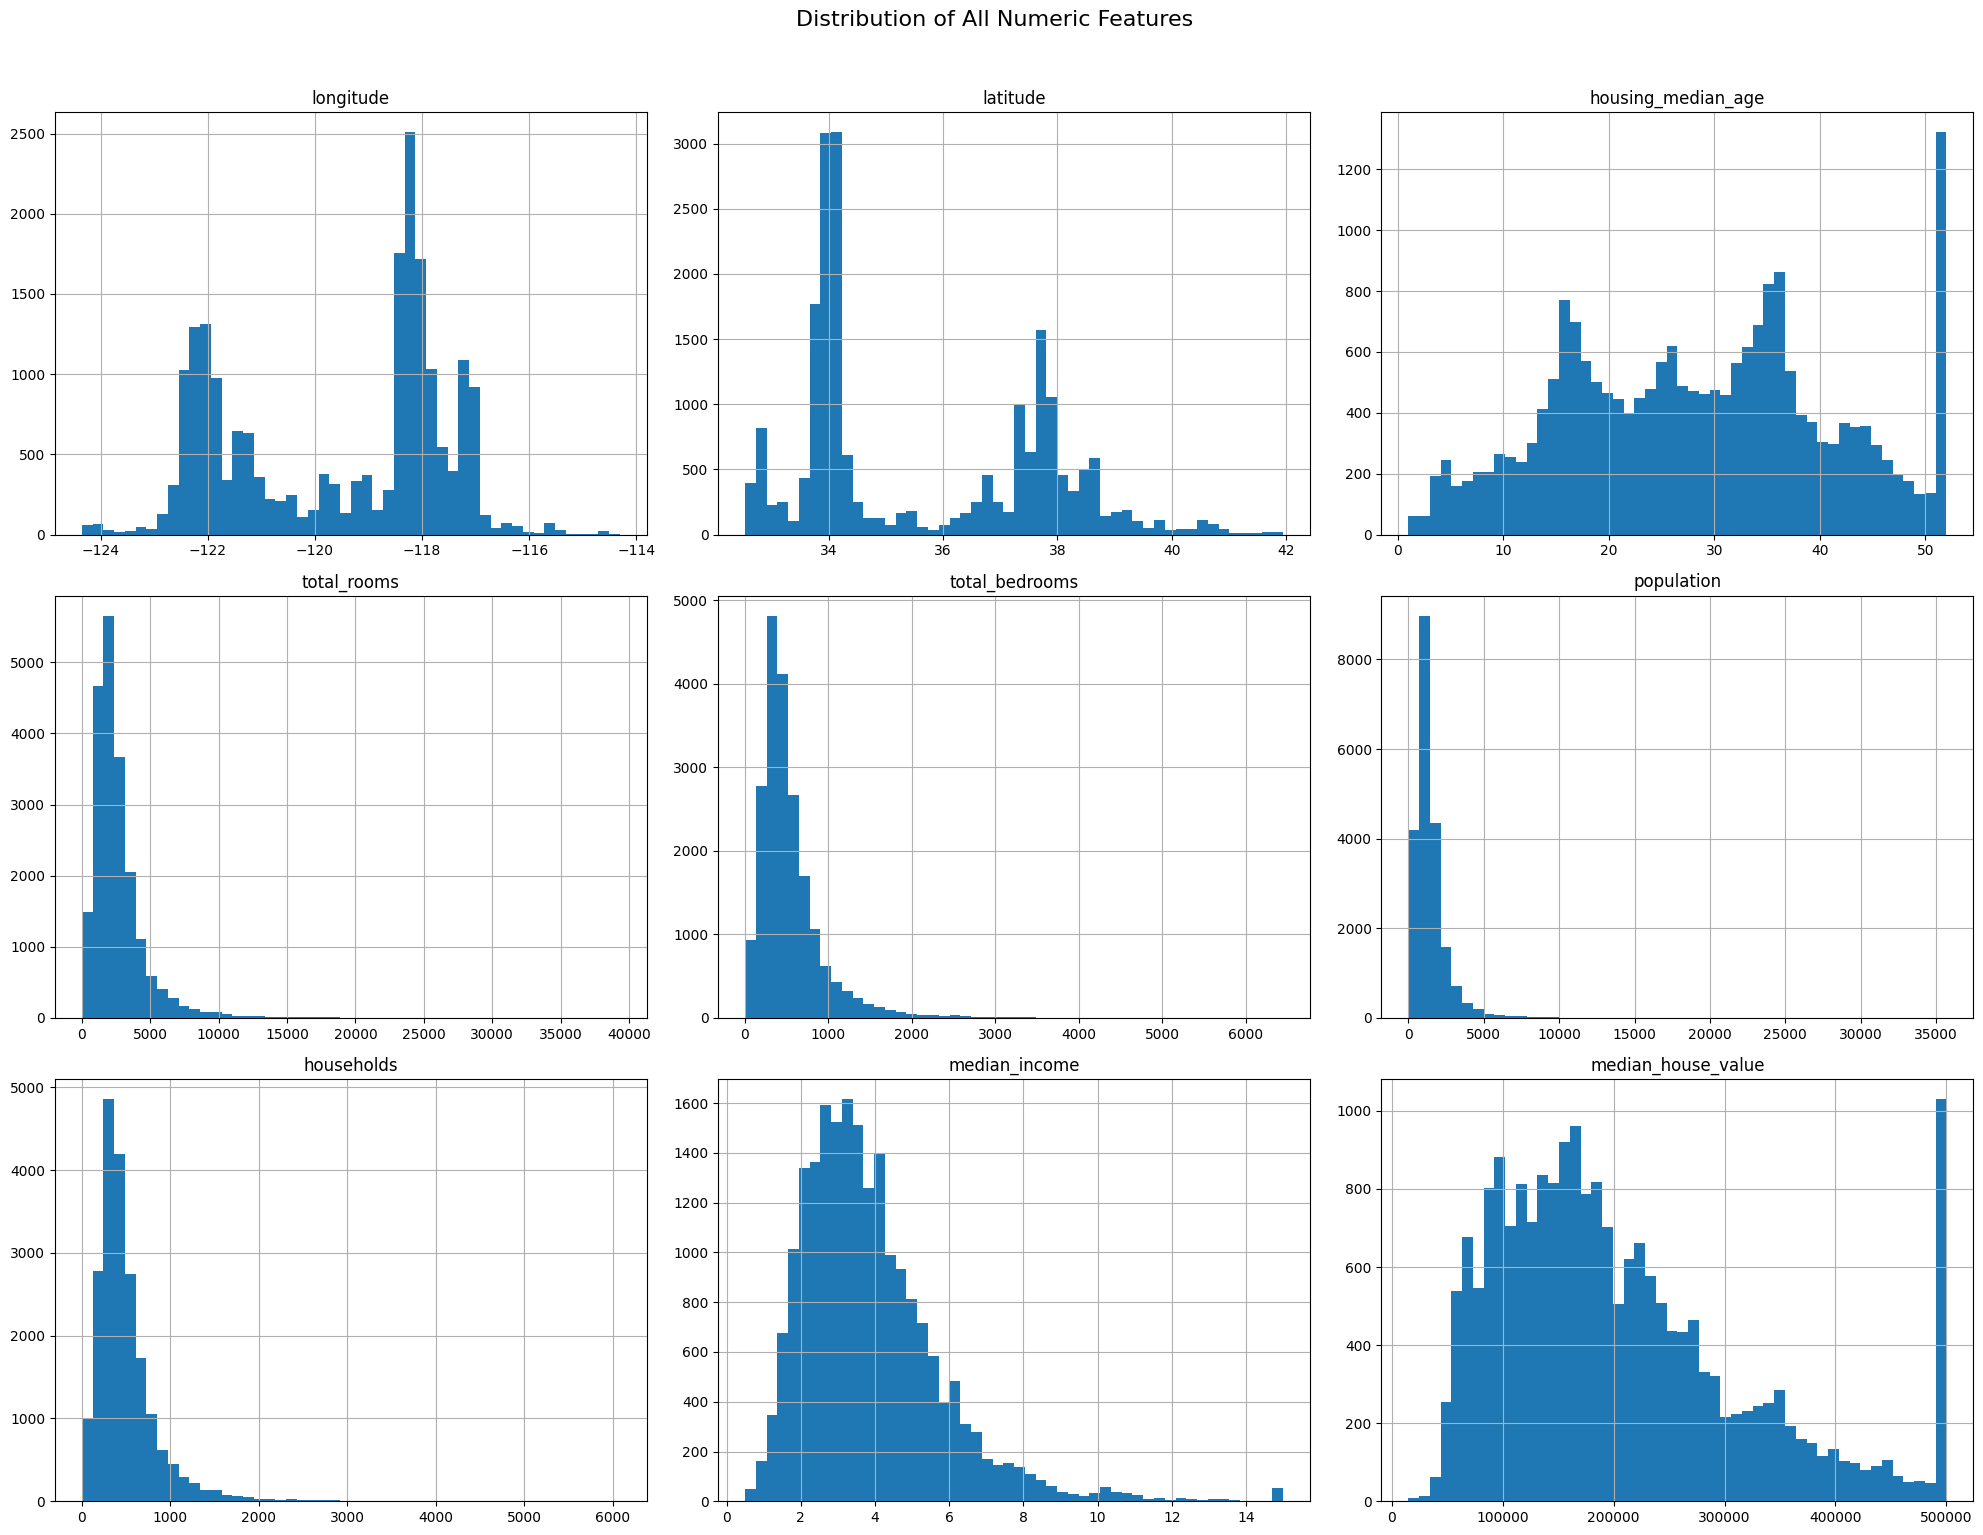

In [15]:
import matplotlib.pyplot as plt

# ─── Plot a histogram for EVERY numeric column in one command ───
housing.hist(bins=50, figsize=(20, 15))

plt.suptitle("Distribution of All Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**housing_median_age**


Huge spike at value 52

Ages were capped at 52.

 Old houses all show 52 even if they're 60, 70, 80 years old

 	Remove capped districts OR collect real values for those districts


**median_house_value**

	Huge spike at $500,000	This is our TARGET.
  
   Values were capped at $500k. Model will wrongly learn that $500k is the maximum possible price

   The book specifically warns: "The median house value was capped at $500,001... This may be a problem... the algorithm may learn that prices never go beyond that limit. You need to check with the team whether this is a problem or not, and if so, you may collect proper labels for those districts whose labels were capped."

In other words: if you train the model without fixing this, it will refuse to ever predict prices above $500k. Any district that should be worth $600k or $800k will be wrongly capped at $500k by the model.
   
   Remove districts where value=$500k OR get real values. The book says this is the most important fix

**median_income**

Spike at 15.0 (=$150k)

Incomes capped at $150k.

 Rich neighborhoods all look the same	Less critical — the book keeps this for simplicity

**total_rooms, total_bedrooms, population**

	Very long right tail —
  
  most districts small, a few districts huge
  
  	Skewed distributions can cause issues for some ML algorithms (though Random Forest handles it)
    
    	Apply log transformation to normalize. The book mentions but doesn't apply in Ch.2

Section 06

**Creating the Train and Test Sets**

قبل أن تنظر إلى البيانات أكثر من ذلك، يجب عليك أن تنشئ مجموعة اختبار ، وتضعها جانباً، ولا تنظر إليها أبداً...
قد يبدو هذا غريباً أن تتجاهل جزءاً من البيانات طواعية، ولكنه في الحقيقة ممارسة جيدة جداً:
إذا نظرت إلى مجموعة الاختبار، قد تصادف بعض الأنماط التي تبدو مثيرة للاهتمام، فيؤدي بك ذلك إلى اختيار نوع معين من نموذج التعلم الآلي أو خيارات معالجة مسبقة معينة.
ثم عندما تقيس خطأ التعميم  باستخدام مجموعة الاختبار، سيكون تقديرك متفائلاً جداً (أي أفضل مما يجب).
يسمي الكتاب هذه الظاهرة  أو "تحيز التجسس على البيانات" — دماغك آلة ممتازة في التعرف على الأنماط.
مجرد أن ترى بيانات الاختبار (حتى لو للحظات قصيرة)، فإن ذلك يؤثر على قراراتك بشكل غير واعي.

Imagine a professor creates a final exam. If the professor accidentally emails the exam to students before the test day, even if students promise not to study it, their brains will remember. Their score will be artificially high — not a true measure of knowledge.

The test set is your "sealed exam." Set it aside the moment you load the data. Don't look at it, don't analyze it, don't graph it. Open it exactly ONCE at the very end to get your honest final score.

Applied to our problem: median_income is the most important predictor of house prices. A random split might accidentally put all rich districts in training and all poor districts in testing — making training unrepresentative.

**Stratified Split (also called Stratified Sampling)** is a special way of dividing a dataset into a **training set and a test set**.
Instead of splitting the data randomly, **we first divide the data into groups (called strata)** based on an important feature — in this project, the median income (MedInc).
We then take exactly the same percentage from each group for the test set (20%) and for the training set (80%).
**This ensures that both the training set and the test set have almost exactly the same distribution of income levels as the original data**. It prevents sampling bias and makes the model evaluation much more honest and reliable.

In [16]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# ════ STAGE 1: Create income categories (5 strata) ════
# np.ceil divides income by 1.5, then rounds UP to nearest integer
# This compresses income (0-15) into categories (1-10+)
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)

# Cap at 5: anything ≥ 5 becomes 5 (all high earners in same category)
# .where(condition, replacement, inplace): keep where True, replace where False
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)

print("Income category distribution:")
print(housing["income_cat"].value_counts().sort_index())

# ════ STAGE 2: Perform stratified split ════
# n_splits=1: do it once (we only need one train/test split)
# test_size=0.2: 20% test, 80% train
# random_state=42: reproducible — same result every run
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# .split(X, stratify_column) returns (train_indices, test_indices) pairs
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set  = housing.loc[test_index]

# ════ STAGE 3: Remove the helper column ════
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"\nTraining set: {len(strat_train_set)} rows")
print(f"Test set:     {len(strat_test_set)} rows")

# Verify: income proportions should match in both sets
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
strat_train_set["income_cat"] = housing.loc[train_index]["income_cat"]
print("\nTrain set income proportions:")
print((strat_train_set["income_cat"].value_counts() / len(strat_train_set)).sort_index())

Income category distribution:
income_cat
1.0     822
2.0    6581
3.0    7236
4.0    3639
5.0    2362
Name: count, dtype: int64

Training set: 16512 rows
Test set:     4128 rows

Train set income proportions:
income_cat
1.0    0.039789
2.0    0.318859
3.0    0.350594
4.0    0.176296
5.0    0.114462
Name: count, dtype: float64


/tmp/ipykernel_13262/2615882174.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
/tmp/ipykernel_13262/2615882174.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

01

housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)

np.ceil(x) = "Ceiling" — always rounds a number UP to the nearest whole integer. Examples: ceil(2.0)=2, ceil(2.1)=3, ceil(4.8)=5, ceil(1.01)=2.

/ 1.5 = Divides every income value by 1.5 first.

 This maps income (0–15 range) to categories (0–10 range).

  Dividing by 1.5 and ceiling creates approximately 5 meaningful groups.

How income_cat values are computed

median_income	÷ 1.5	np.ceil()	After cap	Meaning

0.5 (=$5k)	0.33	1.0	1	Very low income

2.5 (=$25k)	1.67	2.0	2	Low income

4.0 (=$40k)	2.67	3.0	3	Middle income

5.5 (=$55k)	3.67	4.0	4	Upper-middle

8.0 (=$80k)	5.33	6.0	5 (capped)	High income

14.0 (=$140k)	9.33	10.0	5 (capped)	High income

02

housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)

This "caps" all categories at 5. The pandas .where(condition, other) rule: Keep the original value where condition is True. Replace with "other" where condition is False.

Condition = income_cat < 5. Where this is True (values 1,2,3,4): keep them. Where False (values 5,6,7,8,9,10): replace with 5.0.

After this: income_cat only has values 1, 2, 3, 4, or 5. All high earners (category 5, 6, 7...) are merged into category 5.

inplace=True = Modify the actual column in the DataFrame. Without it, the result is returned but the original isn't changed.

03

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

StratifiedShuffleSplit = sklearn class for stratified splitting. Three parameters:

n_splits=1 = Generate 1 train/test pair (we only need one split, not multiple). Setting to 5 would give 5 different splits for 5-fold CV.

test_size=0.2 = 20% of data goes to test, 80% to training. With 20,640 rows: test≈4,128, train≈16,512.

random_state=42 = Seed for reproducibility. Any number works — 42 is just a convention.

StratifiedShuffleSplit = اسم الآلة اللي هتعمل التقسيم الطبقي (Stratified).

n_splits=1 = أعمل تقسيم واحد فقط (مش 5 أو 10).  محتاجين تقسيم واحد فقط.

test_size=0.2 = 20% من البيانات هتروح للـ Test Set، و80% هتبقى Train Set.

random_state=42 = رقم سحري عشان النتيجة تتكرر كل مرة تشغل الكود (مهم جداً عشان النتايج متتغيرش)

هنا بنقول للسكايت ليرن: "اعملي تقسيم طبقي، خدي 20% للاختبار، واستخدمي رقم 42 عشان التقسيم يتكرر نفسو كل مرة."

04

for train_index, test_index in split.split(housing, housing["income_cat"]):

split.split(X, stratify_column) = Execute the split. Returns a generator of (train_indices, test_indices). The second argument tells it which column to use for stratification.

Since n_splits=1, the for loop runs exactly once, giving us train_index and test_index as numpy arrays of row numbers.

🧒 split.split() is like a card-sorting machine. You put 20,640 numbered cards in. It sorts them into two piles: "training pile" (train_index) and "exam pile" (test_index), making sure each income group is proportionally represented in both piles.

split.split(...) = ينفذ التقسيم فعلياً.

housing = كل البيانات.

housing["income_cat"] = العمود اللي بنستخدمه للتقسيم الطبقي (الدخل)

train_index = أرقام الصفوف اللي هتروح للتدريب.
test_index = أرقام الصفوف اللي هتروح للاختبار.

بالعربي:
الآلة بتاخد البيانات كلها + عمود الدخل، وبترجع لنا قائمتين: قائمة أرقام الصفوف للـ التدريب وقائمة أرقام الصفوف للـاختبار


05

strat_train_set = housing.loc[train_index]

.loc[list_of_labels] = Select rows by their INDEX LABEL (the row's ID). This is different from .iloc[list_of_positions] which uses row position numbers.

Why .loc? After shuffling, row labels (IDs) no longer match their position. Row labeled "1042" might be at position 5. .loc finds it by its label (ID), not its position.

.loc[]:اختار الصفوف حسب رقم الأي دي  الأصلي للصف

06

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

Loop through both DataFrames and remove the income_cat column from each. The loop avoids writing the same .drop() twice.

 axis=1 = drop a column (axis=0 = drop a row). inplace=True = modify in place.

Why drop it? income_cat is an artificial column we created only to guide the stratified split. The original dataset doesn't have it, and we don't want the model learning from it.

for set_ in (...) = loop على الـ Train والـ Test مع بعض.

drop("income_cat", axis=1) = احذف عمود income_cat.

inplace=True = عدل الجدول مباشرة (مش تعمل نسخة جديدة).

Section 7

**Explore and Visualize the Data**


"Now you are free to explore the training data a bit. First, let's make a copy of it so you can play with it without harming the training set."

The book is very clear: always work on a copy during exploration. If you accidentally corrupt the data during exploration (add a wrong column, delete rows, change values), your original training set is safe.

**The exploration goal: "find patterns and insights that will help you build a better model."**

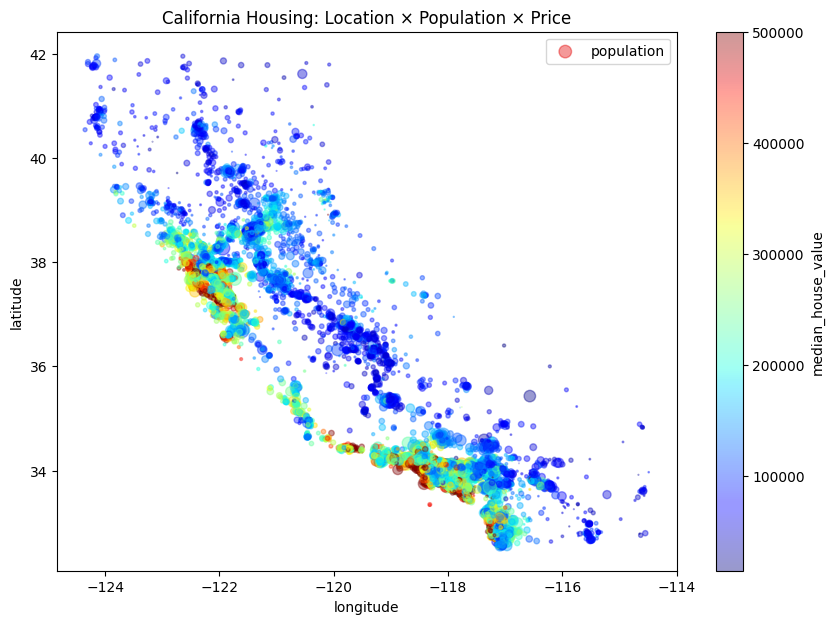

In [17]:
# Always work on a copy — never modify strat_train_set directly
housing = strat_train_set.copy()

# ════════════════════════════════════════════════════════
# GEOGRAPHIC SCATTER PLOT
# - Each dot = one district
# - x, y = longitude, latitude (maps to California geography)
# - dot SIZE = population (big dot = more people)
# - dot COLOR = median house value (red=expensive, blue=cheap)
# ════════════════════════════════════════════════════════
housing.plot(kind="scatter",
             x="longitude",
             y="latitude",
             alpha=0.4,
             s=housing["population"] / 100,
             label="population",
             c="median_house_value",
             cmap="jet",
             colorbar=True,
             legend=True,
             figsize=(10, 7))

plt.title("California Housing: Location × Population × Price")
plt.show()

01

housing = strat_train_set.copy()

.copy() = Creates a completely independent copy of the DataFrame. Without this, housing = strat_train_set would create a reference (alias) — changes to housing would also change strat_train_set. With .copy(), they are fully separate objects.

🧒 Like photocopying a document. The copy and the original are separate. Writing on the copy doesn't change the original. Without .copy(), you'd be writing directly on the original.


02
housing.plot(kind="scatter", x="longitude", y="latitude", ...)
kind="scatter" = Draw a scatter plot — individual dots, one per row. Each dot's position is set by its x and y values.

x="longitude" = X-axis = east-west position. California longitude ranges from about -124 (northwest coast) to -114 (east).

y="latitude" = Y-axis = north-south position. The result visually looks like a map of California.

03

alpha=0.4
Transparency of each dot. Range 0.0 (invisible) to 1.0 (fully solid).

 At 0.4, overlapping dots build up darker — areas with many districts appear darker/denser. This reveals city clusters (San Francisco, Los Angeles) without needing to change dot size.

🧒 Like drawing with transparent ink. One layer = light. Ten layers stacked = dark. Where many districts overlap → dark cluster = city.

04
s=housing["population"] / 100

s = Size of each dot in matplotlib points². We use population divided by 100 to scale it down to reasonable dot sizes. A district with population=5,000 → dot size 50. A district with population=35,000 → dot size 350 (much bigger). Large dots = dense urban areas.

05

c="median_house_value", cmap="jet", colorbar=True
c="median_house_value" = Color each dot according to the value in this column.

cmap="jet" = Color palette: blue→green→yellow→red. Low values = blue (cheap), High values = red (expensive).

colorbar=True = Draw a vertical bar on the right showing which color = which price value.

# The scatter plot looks like a map of California

- Large red/yellow clusters near longitude -122, latitude 37-38
  = San Francisco Bay Area = expensive + dense population

- Large red/yellow cluster near longitude -118, latitude 34
  = Los Angeles = expensive + very large population

- Small blue dots in the interior = inland areas = cheap + sparse

Key insight: location AND population density strongly predict house prices
Coastal = expensive. Inland = cheap. This confirms longitude/latitude matter.


"California's housing prices are very much related to the location (e.g., close to the ocean) and to the population density." This confirms that latitude, longitude, and population are useful features — and it motivates future feature engineering like "distance to the coast."

Section 08

**Finding Correlations**

What Correlation Values Mean

-1.0

Perfect negative
X↑ → Y↓ always

-0.5
Moderate negative
X↑ → Y tends ↓

0.0
No correlation
No linear link

+0.5
Moderate positive
X↑ → Y tends ↑

+1.0
Perfect positive
X↑ → Y↑ always

Important note: correlation only measures LINEAR relationships — it can miss curved relationships entirely.



Correlations with median_house_value:
median_house_value    1.000000
median_income         0.688380
income_cat            0.642887
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


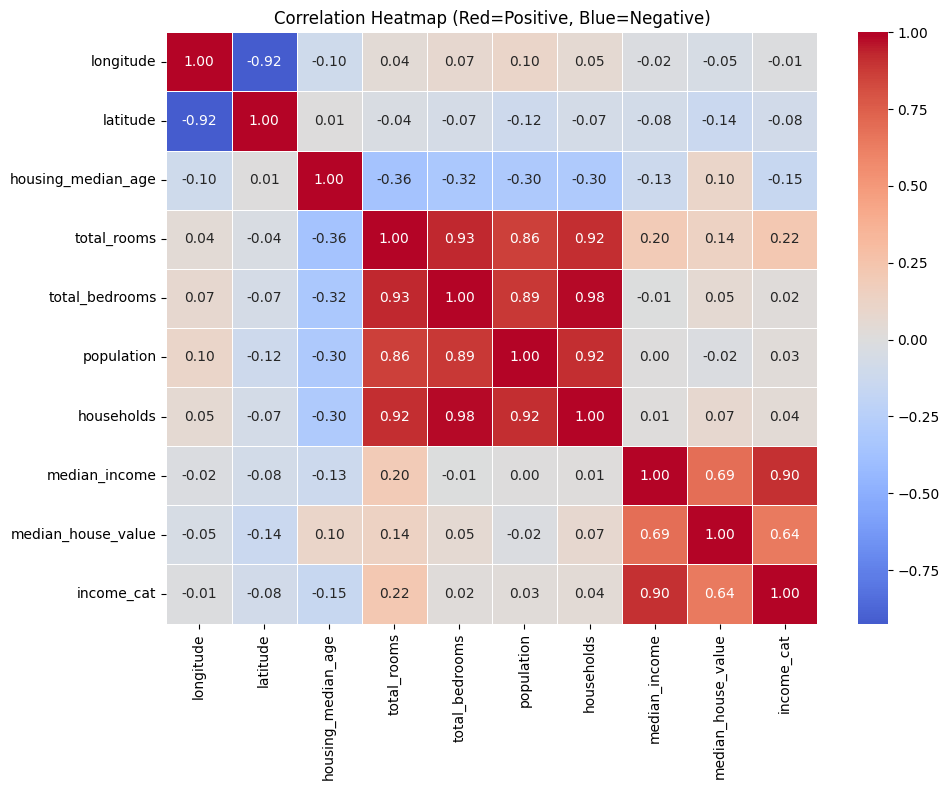

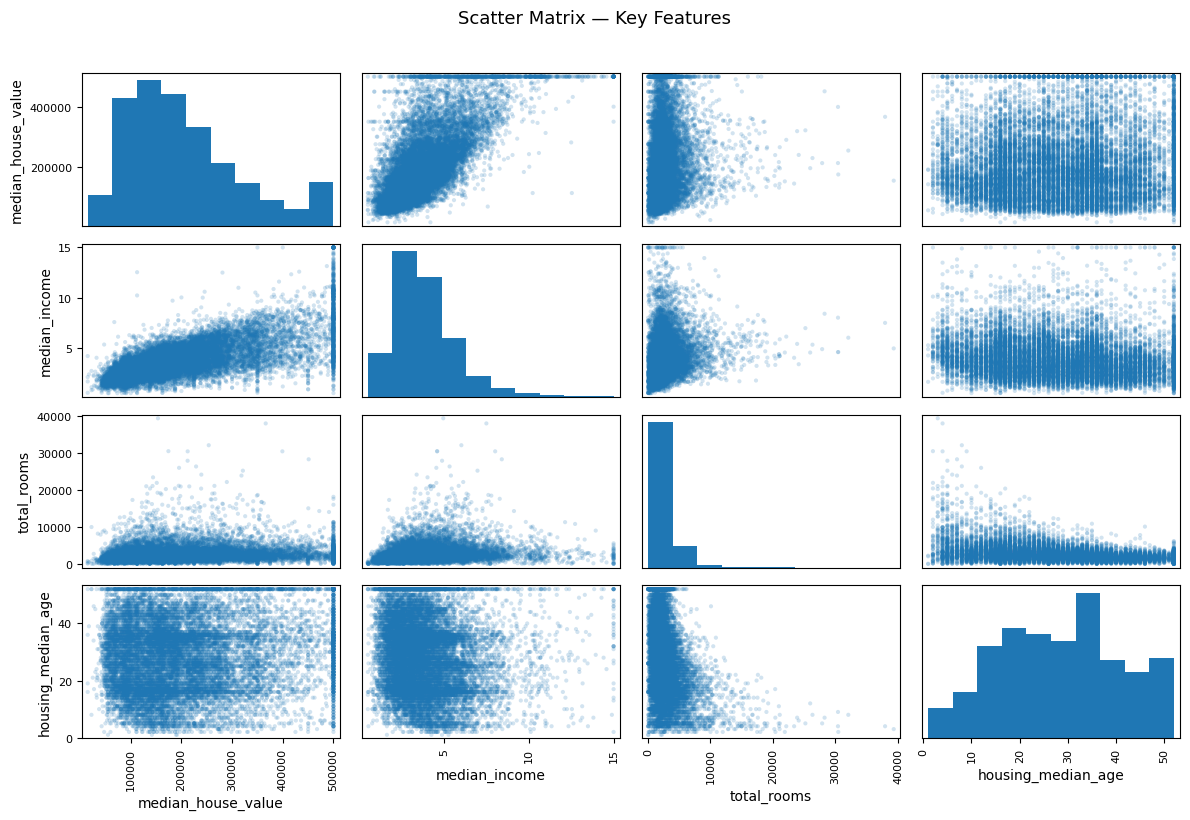

In [18]:
import seaborn as sns

# ════ Compute correlations between ALL numeric columns ════
# Result: a 9×9 table where each cell = correlation between 2 columns
# numeric_only=True: skip text columns (ocean_proximity can't be correlated)
corr_matrix = housing.corr(numeric_only=True)

# ════ Extract correlations specifically with the TARGET ════
price_corr = corr_matrix["median_house_value"].sort_values(ascending=False)
print("Correlations with median_house_value:")
print(price_corr)

# ════ Visualize as heatmap ════
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            ax=ax)
plt.title("Correlation Heatmap (Red=Positive, Blue=Negative)")
plt.tight_layout()
plt.show()

# ════ Scatter matrix for key features ════
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income",
              "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8), alpha=0.2)
plt.suptitle("Scatter Matrix — Key Features", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

01

corr_matrix = housing.corr(numeric_only=True)

.corr() = Computes the Pearson correlation coefficient between every pair of numeric columns. Returns a square DataFrame where row i, column j = correlation between feature i and feature j. The diagonal is always 1.0 (every column is perfectly correlated with itself).

numeric_only=True = Skip non-numeric columns. Without this, pandas would throw an error when it tries to correlate the text column ocean_proximity.

02

corr_matrix["median_house_value"].sort_values(ascending=False)

corr_matrix["median_house_value"] = Select just one column from the correlation matrix — specifically, the column showing correlations with our target variable. Returns a Series of 9 values.

.sort_values(ascending=False) = Sort from highest to lowest (descending). This shows the most strongly correlated features first, making it easy to spot the most useful predictors.

03

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

sns.heatmap() = Draw a color-coded grid showing all correlation values at once.

annot=True = Print the actual number inside each cell (so you can read the value, not just see the color).

fmt=".2f" = Format numbers to 2 decimal places: 0.688 → 0.69.

cmap="coolwarm" = Red for positive correlation, Blue for negative, White for 0.

center=0 = Make 0 the neutral white color (so the color scale is symmetric around 0).

04

scatter_matrix(housing[attributes], figsize=(12,8), alpha=0.2)

scatter_matrix() = Creates a grid of scatter plots for multiple features.

 For n features, creates an n×n grid. Diagonal = histogram of each feature.
  Off-diagonal = scatter plot of each feature pair. With 4 features → 4×4 = 16 charts total.

alpha=0.2 = Very transparent dots. With 16,000+ dots, full opacity would create a solid black blob. High transparency shows density patterns.

محور  الرأسي (المحور العمودي) في كل الرسومات دي يعبر عن "عدد الأحياء" (عدد المناطق ).


The book says about the income-price scatter plot: "This plot reveals a few things. First, the correlation is indeed very strong; you can clearly see the upward trend... Third, you can see a few horizontal lines: one at $500,000... These price caps you noticed earlier are clearly visible."

The horizontal lines prove the cap problem is real — thousands of houses are shown at exactly $500k when they should be higher.

Section 09

**Experimenting with Attribute Combinations** **(Feature Engineering)**

The book demonstrates feature engineering: combining existing columns to create new features that are more meaningful. This is often called "domain knowledge" — understanding what the numbers actually mean in the real world.

Why does bedrooms_ratio work so much better?

Consider two houses: House A: 10 rooms total, 8 bedrooms → ratio = 0.8 (mostly bedrooms = cramped, cheap) House B: 10 rooms total, 2 bedrooms → ratio = 0.2 (lots of living space = luxurious, expensive)

The ratio captures something the raw numbers couldn't: the quality of space!

In [19]:
# FEATURE ENGINEERING: Create better combined features
# ════════════════════════════════════════════════════

# rooms_per_house: more rooms per household = nicer house = more expensive?
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]

# bedrooms_ratio: fewer bedrooms relative to total rooms = more living space
# A house with 10 rooms and 2 bedrooms = 0.2 ratio = luxury (more living rooms)
# A house with 10 rooms and 8 bedrooms = 0.8 ratio = cramped dormitory
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]

# people_per_house: crowding measure — more people per household = cheaper?
housing["people_per_house"] = housing["population"] / housing["households"]

# Check how these new features correlate with house prices
corr_matrix = housing.corr(numeric_only=True)
new_feature_corrs = corr_matrix["median_house_value"][[
    "rooms_per_house", "bedrooms_ratio", "people_per_house",
    "total_rooms", "total_bedrooms", "population"
]].sort_values(ascending=False)
print(new_feature_corrs)

rooms_per_house     0.143663
total_rooms         0.137455
total_bedrooms      0.054635
population         -0.020153
people_per_house   -0.038224
bedrooms_ratio     -0.256397
Name: median_house_value, dtype: float64


Correlations with median_house_value:

# NEW features:
rooms_per_house    0.143   ← better than total_rooms (0.137)

bedrooms_ratio    -0.259   ← MUCH BETTER than total_bedrooms (0.048)!

people_per_house  -0.038

# OLD features (for comparison):
total_rooms        0.137

total_bedrooms     0.048   ← much weaker than bedrooms_ratio

population        -0.115

# bedrooms_ratio jumped from 0.048 → -0.259 (5× more informative!)
# This proves feature engineering matters more than raw data

Section 10

**Prepare the Data for ML Algorithms**

Three main data problems to solve:
(1) Fill Missing values (SimpleImputer)

"Most ML algorithms cannot work with missing features, so let's create a few functions to take care of them. You have three options:
(A) Get rid of the corresponding districts.

Drop rows

	housing.dropna(subset=["total_bedrooms"])
  
 Use when Very few missing (<1%) and rows not critical
  
  Problem:Loses data; only 207 rows here = fine but wasteful

(B) Get rid of the whole attribute.

Drop column

	housing.drop("total_bedrooms", axis=1)
  
 Use when Column is mostly empty or not useful
  
  Problem:	total_bedrooms IS useful — losing it hurts the model

(C) Set the values to some value (zero, the mean, or the median). This is called imputation."

SimpleImputer(strategy="median")

Use with ✅ Most cases — especially numeric columns

Problem:Introduces slight inaccuracy but keeps all data

The book recommends option 3 with the median: it's robust to outliers (unlike mean), and it keeps all 20,640 rows.



 (2) Text/categorical features (OneHotEncoder)

 The key insight: OrdinalEncoder assigns 0,1,2,3,4 to categories, which implies ordering (INLAND=0 is "less than" NEAR BAY=1). OneHotEncoder avoids this — each category becomes its own binary column, completely independent.

 Before (text)

ocean_proximity

INLAND

NEAR BAY

INLAND

NEAR OCEAN

<1H OCEAN

After (5 binary columns)

1H INL ISL BAY OCN

0 1 0 0 0 ← INLAND

0 0 0 1 0 ← NEAR BAY

0 1 0 0 0 ← INLAND

0 0 0 0 1 ← NEAR OCEAN

1 0 0 0 0 ← <1H OCEAN

  (3) Different numerical scales.(Feature Scaling)

  "One of the most important transformations you need to apply to your data is feature scaling. With few exceptions, ML algorithms don't perform well when the input numerical attributes have very different scales."

The book explains two main methods: Min-Max Scaling (Normalization) and Standardization. It recommends Standardization for most cases because it's less sensitive to outliers.

Without scaling: median_income ranges 0–15, but total_rooms ranges 0–40,000. The model might think total_rooms is 2,666× more important just because its numbers are larger!

With StandardScaler: every column has mean=0 and std=1. A value of "1.5" in any column means "1.5 standard deviations above average" — they're now on the same scale and can be compared fairly.

MinMaxScaler

(x - min) / (max - min)

Output Range:0.0 to 1.0

Sensitive to Outliers

Best for Neural networks, image pixels

StandardScaler

(x - mean) / std

Output Range:Roughly -3 to +3
(mean=0, std=1)

Not Sensitive to Outliers

Best for Most ML algorithms (recommended)





In [20]:
from sklearn.impute import SimpleImputer

# ════ STEP 1: Separate features from the target ════
housing      = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

# ════ STEP 2: SimpleImputer only works on numeric columns ════
# Drop the text column temporarily
housing_num = housing.drop("ocean_proximity", axis=1)

# ════ STEP 3: Create and fit the imputer ════
# strategy="median" = fill NaN with the column's median value
# (median is better than mean for skewed data — less affected by outliers)
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)

# See what median values it learned
print("Learned medians:")
for col, val in zip(housing_num.columns, imputer.statistics_):
    print(f"  {col}: {val:.2f}")

# ════ STEP 4: Apply the transformation ════
X = imputer.transform(housing_num)
# X is now a NumPy array (not a DataFrame) with all NaN filled

# Convert back to DataFrame if you want column names
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
print(f"\nMissing values after imputation: {housing_tr.isnull().sum().sum()}")

Learned medians:
  longitude: -118.51
  latitude: 34.26
  housing_median_age: 29.00
  total_rooms: 2125.00
  total_bedrooms: 434.00
  population: 1167.00
  households: 408.00
  median_income: 3.54
  income_cat: 3.00

Missing values after imputation: 0


01


housing = strat_train_set.drop("median_house_value", axis=1)

Separates features (X) from the target label (y). .drop("median_house_value", axis=1) removes the price column and keeps everything else (8 remaining columns become our features). axis=1 = drop a column (not a row).

We must NEVER include the answer column in our features — the model would trivially "predict" the answer because it can see it.

02

imputer = SimpleImputer(strategy="median")

Creates an imputer object configured to fill missing values with the median. Other options: strategy="mean" (arithmetic average), strategy="most_frequent" (most common value — good for categories), strategy="constant" (fill with a specific value you provide).

Why median over mean? Median is more robust to outliers. For total_bedrooms: if 99% of districts have 100–500 bedrooms but a few have 10,000, the mean would be pulled high. The median stays near the "typical" value.

03

imputer.fit(housing_num)

.fit(data) = Learning phase. The imputer scans every column of housing_num and computes the median of each. It stores these 8 median values in imputer.statistics_. No data is transformed yet — this is just learning the values to use.

🧒 Like a nurse measuring every patient's average normal temperature before the clinic opens. She doesn't treat anyone yet — she just learns what "normal" looks like. Later she uses that knowledge to fill in missing temperatures.

04

X = imputer.transform(housing_num)

.transform(data) = Application phase. Using the medians learned during .fit(), replace every NaN in the data with the corresponding column's median. Returns a NumPy array (not a DataFrame — column names are lost).

⚠️** On the test set: NEVER call .fit() again. Call .transform() only, using the medians learned from the training set. If you .fit() on the test set, the imputer learns different medians from the test data — that's data leakage.**

05

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

pd.DataFrame(X, ...) = Convert the NumPy array back to a pandas DataFrame. Three arguments: the data (X), the column names (same as before), the row index (same as before — important for alignment with other data).

06

housing_tr.isnull().sum().sum()

.isnull() = Creates a DataFrame of True/False — True where NaN exists. .sum() = Sum each column (True=1, False=0) → gives count of NaN per column. .sum() again = Sum across all columns → total NaN count in the whole DataFrame. Should be 0 after imputation.

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Get the text column (as a DataFrame, not a Series)
housing_cat = housing[["ocean_proximity"]]

# Create the encoder
# sparse_output=False: return a regular dense array (easier to work with)
# default sparse=True returns a memory-efficient sparse matrix
cat_encoder = OneHotEncoder(sparse_output=False)

# fit_transform: learn the 5 categories AND convert to numbers in one step
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print("Categories found:", cat_encoder.categories_)
print(f"Shape: {housing_cat_1hot.shape}")
print("\nFirst 3 rows encoded:")
print(housing_cat_1hot[:3])

Categories found: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
Shape: (16512, 5)

First 3 rows encoded:
[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


01

housing_cat = housing[["ocean_proximity"]]

Note the double brackets [[...]]. Single bracket housing["ocean_proximity"] returns a Series (1D). Double bracket housing[["ocean_proximity"]] returns a DataFrame (2D with column name). OneHotEncoder expects a 2D DataFrame, not a 1D Series — so we must use double brackets.

02

cat_encoder.categories_

After fitting, this attribute stores the unique categories found, in the order they were encoded: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'])]. This order tells you which column position corresponds to which category (column 0 = <1H OCEAN, column 1 = INLAND, etc.).

Section 11

**Transformation Pipelines**

There are many data transformation steps that need to be executed in the right order. Scikit-Learn provides the Pipeline class to help with such sequences of transformations. Here is a small pipeline for the numerical attributes."

The book's key reasons for using pipelines:

(1) Reproducibility — always apply the same steps in the same order.

(2) No manual errors — the pipeline handles the sequence.

 (3) Reuse — apply to any new data.

  (4) Cross-validation compatible — sklearn treats the whole pipeline as a single estimator.

In [22]:
from sklearn.pipeline  import Pipeline
from sklearn.compose   import ColumnTransformer
from sklearn.impute    import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ═══ Define which columns are numeric vs categorical ═══
num_attribs = ["longitude", "latitude", "housing_median_age",
               "total_rooms", "total_bedrooms", "population",
               "households", "median_income"]
cat_attribs = ["ocean_proximity"]

# ═══ Pipeline for NUMERIC columns ═══
# Step 1: SimpleImputer fills NaN with median
# Step 2: StandardScaler normalizes to mean=0, std=1
num_pipeline = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])

# ═══ ColumnTransformer: apply different pipelines to different columns ═══
# ("name", transformer, which_columns)
# "num" path: apply num_pipeline to numeric columns
# "cat" path: apply OneHotEncoder to text column
full_pipeline = ColumnTransformer([
    ("num", num_pipeline,      num_attribs),
    ("cat", OneHotEncoder(),   cat_attribs),
])

# ═══ Apply to training data ═══
# fit_transform: learn parameters (medians, mean/std, categories) AND apply
housing_prepared = full_pipeline.fit_transform(housing)

print(f"Before: {housing.shape}")
print(f"After:  {housing_prepared.shape}")

Before: (16512, 10)
After:  (16512, 13)


01

num_pipeline = Pipeline([("imputer", SimpleImputer(...)), ("std_scaler", StandardScaler())])

Pipeline([ list of (name, transformer) tuples ]) chains transformers in order. Each tuple has a name (any string you choose — used for debugging and parameter tuning) and a transformer.

When you call num_pipeline.fit_transform(data),

 it runs: data → SimpleImputer → output → StandardScaler → final output.

  The output of each step becomes the input to the next.

🧒 A pipeline is like a factory assembly line. Raw steel enters. Station 1 (imputer): fills holes. Station 2 (scaler): polishes to uniform size. Finished part exits. Each station feeds the next automatically.


02

ColumnTransformer([("num", num_pipeline, num_attribs),

 ("cat", OneHotEncoder(), cat_attribs)])

ColumnTransformer applies DIFFERENT transformers to DIFFERENT sets of columns simultaneously.

 Each entry: (name, transformer, column_list).

The "num" transformer gets the 8 numeric columns and runs them through num_pipeline (impute + scale).

The "cat" transformer gets the 1 text column and runs it through OneHotEncoder.

Results are concatenated horizontally: 8 scaled columns + 5 one-hot columns = 13 total columns.

03

housing_prepared = full_pipeline.fit_transform(housing)

fit_transform(X) = In one call:

(1) learn all parameters (median of each column, mean/std for scaler, 5 category names for encoder) from the data,

(2) apply those parameters to transform the data.

⚠️ CRITICAL RULE: fit_transform() ONLY on training data.

 On the test set, ALWAYS use .transform() — never .fit_transform().

 Re-fitting on test data = data leakage. The preprocessing parameters must come from training data only.

 Output

Before: (16512, 9)

After:  (16512, 13)

# 9 columns became 13 because:

# 8 numeric columns (imputed + scaled) = 8

# 1 ocean_proximity text column → OneHot → 5 columns = 5

# Total: 8 + 5 = 13

Section 12

**Select and Train a Model**

"At last! You framed the problem, you got the data and explored it, you sampled a training set and a test set, and you wrote transformation pipelines to clean up and prepare your data for ML algorithms automatically. You are now ready to select and train a ML model."

The book's strategy: Start simple, measure honestly. Try a simple model first to get a baseline. Then try more complex models. Always use cross-validation — never judge a model on its training error alone.





In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree         import DecisionTreeRegressor
from sklearn.ensemble     import RandomForestRegressor
from sklearn.metrics      import mean_squared_error

# ════════════ MODEL 1: Linear Regression ════════════
# Draws the best straight line/hyperplane through the data
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

lin_preds = lin_reg.predict(housing_prepared)
lin_rmse  = np.sqrt(mean_squared_error(housing_labels, lin_preds))
print(f"Linear Reg  Training RMSE: ${lin_rmse:,.0f}")

# ════════════ MODEL 2: Decision Tree ════════════
# A flowchart of yes/no questions — can fit complex patterns
# BUT tends to memorize training data (overfitting)
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

tree_preds = tree_reg.predict(housing_prepared)
tree_rmse  = np.sqrt(mean_squared_error(housing_labels, tree_preds))
print(f"Decision Tree Training RMSE: ${tree_rmse:,.0f}")

# ════════════ MODEL 3: Random Forest ════════════
# 100+ Decision Trees, each trained on random data/feature subsets
# Averages all predictions — reduces overfitting dramatically
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

forest_preds = forest_reg.predict(housing_prepared)
forest_rmse  = np.sqrt(mean_squared_error(housing_labels, forest_preds))
print(f"Random Forest Training RMSE: ${forest_rmse:,.0f}")

Linear Reg  Training RMSE: $68,233
Decision Tree Training RMSE: $0
Random Forest Training RMSE: $18,058


01

lin_reg = LinearRegression()

Creates an empty model — no weights learned yet. This is just a blueprint. The model doesn't know anything about house prices yet. Called "instantiation" — creating an instance of the LinearRegression class.

🧒 Like buying a blank notebook. The notebook exists but has nothing written in it yet. .fit() is the act of writing in the notebook.

02

lin_reg.fit(housing_prepared, housing_labels)

THE most important line in any ML workflow. Finds the best equation to map input features to output prices. For Linear Regression, this means finding numbers (coefficients) for: price = w₁×longitude + w₂×latitude + w₃×income + ... + bias. These coefficients are found using math (least squares optimization).

03

DecisionTreeRegressor(random_state=42)

random_state=42 = Seed for reproducibility. Decision Trees have some internal randomness in how they choose split points when scores are tied. Setting a fixed seed ensures you get the same tree every run. The number 42 is just convention — any integer works.

04

RandomForestRegressor(random_state=42)

Creates a forest of 100 Decision Trees (default n_estimators=100). Each tree is trained on a random bootstrap sample of the training data AND uses a random subset of features at each split. This double randomness forces diversity among the trees, which dramatically reduces overfitting compared to a single tree.

Output — The Surprising Results

Linear Reg   Training RMSE: $68,233

# Consistently bad — off by $68k on average
# This is UNDERFITTING: model too simple for the data

Decision Tree Training RMSE: $0

# PERFECT score on training — but this is OVERFITTING!
# The tree memorized all 16,512 training rows
# It will perform terribly (~$71k) on new unseen data

Random Forest Training RMSE: $18,058

# Better than linear, but still optimistic
# Cross-validation will reveal the true score (~$47k)

The book says: "The Decision Tree model has badly overfit the data: it scores 0.0 on training data... Clearly the model has learned the training set by heart."

A $0 RMSE on training data is a red flag, NOT a success. The model simply memorized all training examples like a student who memorized the answer key. Show it ONE new question and it fails.

The only honest performance estimate comes from cross-validation — evaluating on data the model never trained on.

Section 13

Cross-Validation

"K-fold cross-validation randomly splits the training set into 10 distinct subsets called folds, then it trains and evaluates the model 10 times, picking a different fold for evaluation every time and training on the other 9 folds. The result is an array containing the 10 evaluation scores."

Cross-validation solves the fundamental dilemma: we cannot use the test set (it's sealed), but we cannot trust training error (too optimistic). CV creates multiple "mini test sets" from the training data — giving honest estimates without touching the real test set.

Round 1

TEST
T
T
T
T
T
T
T
T
T
→ RMSE₁


Round 2

T
TEST
T
T
T
T
T
T
T
T
→ RMSE₂


Round 3


T
T
TEST
T
T
T
T
T
T
T
→ RMSE₃




──────────────────────────────────────────
  Linear Regression
──────────────────────────────────────────
  Per-fold RMSE ($k): [69.8 67.7 67.3 69.1 67.3 68.7 67.4 70.  67.5 68.3]
  Mean RMSE:   $    68,316
  Std Dev:     $       972
  Min RMSE:    $    67,256
  Max RMSE:    $    69,952

──────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────
  Per-fold RMSE ($k): [69.1 67.2 67.4 70.  68.5 71.5 71.  68.7 67.3 66.6]
  Mean RMSE:   $    68,731
  Std Dev:     $     1,585
  Min RMSE:    $    66,648
  Max RMSE:    $    71,464

──────────────────────────────────────────
  Random Forest
──────────────────────────────────────────
  Per-fold RMSE ($k): [48.5 50.  47.5 49.3 48.4 49.1 48.5 49.5 48.9 49.4]
  Mean RMSE:   $    48,901
  Std Dev:     $       671
  Min RMSE:    $    47,505
  Max RMSE:    $    50,000


/tmp/ipykernel_13262/3980584520.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([lin_cv/1000, tree_cv/1000, forest_cv/1000],


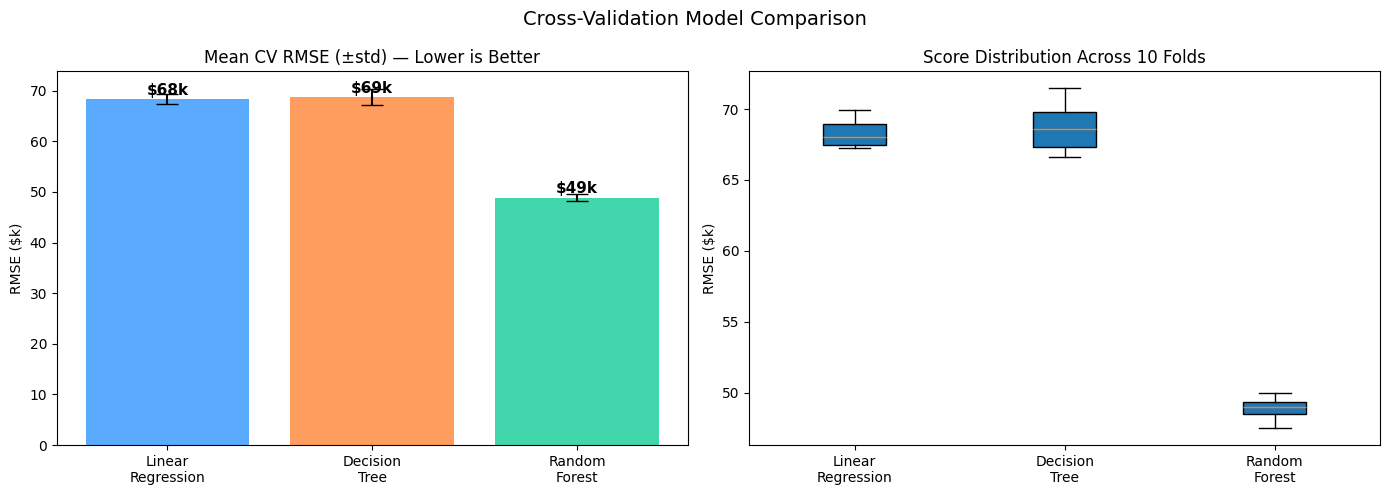

In [24]:
from sklearn.model_selection import cross_val_score

def display_cv_scores(model, name, X, y, cv=10):
    # cross_val_score does the whole loop: split → train → evaluate → repeat
    # scoring="neg_mean_squared_error": returns NEGATIVE MSE
    # (sklearn uses "higher=better" convention, so MSE is negated)
    # cv=10: split into 10 folds
    scores = cross_val_score(model, X, y,
                             scoring="neg_mean_squared_error", cv=cv)

    # Convert neg MSE → positive RMSE in two steps:
    # Step 1: -scores removes the negative sign → positive MSE
    # Step 2: np.sqrt() converts squared-dollars → regular dollars
    rmse_scores = np.sqrt(-scores)

    print(f"\n{'─'*42}")
    print(f"  {name}")
    print(f"{'─'*42}")
    print(f"  Per-fold RMSE ($k): {np.round(rmse_scores/1000,1)}")
    print(f"  Mean RMSE:   ${rmse_scores.mean():>10,.0f}")
    print(f"  Std Dev:     ${rmse_scores.std():>10,.0f}")
    print(f"  Min RMSE:    ${rmse_scores.min():>10,.0f}")
    print(f"  Max RMSE:    ${rmse_scores.max():>10,.0f}")
    return rmse_scores

lin_cv    = display_cv_scores(lin_reg,    "Linear Regression", housing_prepared, housing_labels)
tree_cv   = display_cv_scores(tree_reg,   "Decision Tree",    housing_prepared, housing_labels)
forest_cv = display_cv_scores(forest_reg, "Random Forest",    housing_prepared, housing_labels)

# ════════ Bar chart comparison ════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names  = ["Linear\nRegression", "Decision\nTree", "Random\nForest"]
means  = [lin_cv.mean(), tree_cv.mean(), forest_cv.mean()]
stds   = [lin_cv.std(),  tree_cv.std(),  forest_cv.std()]
colors = ["#3d9bff", "#ff8c42", "#1fcf9e"]

# LEFT: Bar chart with error bars showing std deviation
bars = axes[0].bar(names, [m/1000 for m in means],
                   yerr=[s/1000 for s in stds],
                   color=colors, alpha=0.85, capsize=8)

# Add value labels above each bar
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f"${mean/1000:.0f}k",
                ha="center", fontsize=11, fontweight="bold")

axes[0].set_title("Mean CV RMSE (±std) — Lower is Better")
axes[0].set_ylabel("RMSE ($k)")

# RIGHT: Box plot showing spread across 10 folds
axes[1].boxplot([lin_cv/1000, tree_cv/1000, forest_cv/1000],
               labels=names, patch_artist=True)
axes[1].set_title("Score Distribution Across 10 Folds")
axes[1].set_ylabel("RMSE ($k)")

plt.suptitle("Cross-Validation Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

★

scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)

cross_val_score() = The whole 10-fold CV loop in one line. Splits X into 10 folds, trains 10 times, evaluates 10 times, returns 10 scores.

scoring="neg_mean_squared_error" = Use MSE as metric but negate it. Why? sklearn standardizes on "higher score = better model." MSE is lower = better, so sklearn negates it: -MSE is higher when MSE is lower. The neg_ prefix is the signal.

Returns: array of 10 negative numbers, e.g., [-2.1B, -2.3B, -2.0B, -2.2B, -2.1B, -2.4B, -2.0B, -2.2B, -2.1B, -2.3B]

★

rmse_scores = np.sqrt(-scores)

The two-step conversion: -scores negates all values (making them positive MSE), then np.sqrt() takes the root of each, converting from squared-dollars to regular-dollars RMSE.

Example: -2,100,000,000 → +2,100,000,000 → √2,100,000,000 ≈ $45,826 (RMSE for that fold)

★

f" Mean RMSE: ${rmse_scores.mean():>10,.0f}"
rmse_scores.mean() = Average of the 10 fold RMSE values.

:>10,.0f = Format specifier: > = right-align, 10 = in a field 10 characters wide, , = thousands separator, .0f = 0 decimal places.

The >10 makes all numbers line up in a column for readability — $47,900 and $68,100 both aligned at the same width.

★

bars = axes[0].bar(names, [m/1000 for m in means], yerr=[s/1000 for s in stds], capsize=8)

[m/1000 for m in means] = List comprehension: create a new list by dividing each mean by 1000. Converts from dollars to thousands ($47,900 → 47.9). Shorter labels on the chart.

yerr=[s/1000 for s in stds] = Error bars showing ±standard deviation. A tall error bar means the model's performance varies a lot across folds (unstable). Short error bar = consistent.

capsize=8 = Width (8 pixels) of the horizontal cap at the top and bottom of each error bar.

★

for bar, mean in zip(bars, means):
  axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.8, f"${mean/1000:.0f}k", ha="center")

zip(bars, means) = Pair each bar with its mean value: [(bar1,$69k),(bar2,$71k),(bar3,$47k)].

bar.get_x() + bar.get_width()/2 = X position = left edge of bar + half of bar width = center of bar.

bar.get_height() + 0.8 = Y position = top of bar + 0.8 units padding (so label doesn't overlap bar).

ha="center" = "Horizontal Alignment = center" — centers the text at the X position.

Output:

Linear Regression
──────────────────────────────────────────
  Per-fold RMSE ($k): [69.8 67.7 67.3 69.1 67.3 68.7 67.4 70.  67.5 68.3]

  Mean RMSE:   $    68,316

  Std Dev:     $       972

  Min RMSE:    $    67,256

  Max RMSE:    $    69,952

──────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────
  Per-fold RMSE ($k): [69.1 67.2 67.4 70.  68.5 71.5 71.  68.7 67.3 66.6]

  Mean RMSE:   $    68,731

  Std Dev:     $     1,585

  Min RMSE:    $    66,648

  Max RMSE:    $    71,464

──────────────────────────────────────────
  Random Forest
──────────────────────────────────────────
  Per-fold RMSE ($k): [48.5 50.  47.5 49.3 48.4 49.1 48.5 49.5 48.9 49.4]

  Mean RMSE:   $    48,901

  Std Dev:     $       671

  Min RMSE:    $    47,505
  
  Max RMSE:    $    50,000

Section 14

**Fine-Tune Your Model (Adjust Hyperparameter and choose their best Values using GridSearchCV)**

"Let's assume that you now have a shortlist of promising models. You now need to fine-tune them. One way to do that is to fiddle with the hyperparameters manually, until you find a great combination of hyperparameter values. This would be very tedious work... instead, you should get Scikit-Learn's GridSearchCV to do this exploration for you."



In [25]:
from sklearn.model_selection import GridSearchCV

# ════ DEFINE THE GRID ════
# A list of dictionaries. Each dict = one group of combinations.
# GridSearch tries ALL combos within each dict.
# Group 1: 3 × 4 = 12 combinations (bootstrap=True by default)
# Group 2: 1 × 2 × 3 = 6 combinations (bootstrap=False)
# Total: 18 combinations × 5-fold CV = 90 training runs
param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]}
]

forest_reg2 = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator          = forest_reg2,
    param_grid         = param_grid,
    cv                 = 5,
    scoring            = "neg_mean_squared_error",
    return_train_score = True
)
grid_search.fit(housing_prepared, housing_labels)

print("Best params:", grid_search.best_params_)
print(f"Best CV RMSE: ${np.sqrt(-grid_search.best_score_):,.0f}")

# ════ RANDOMIZED SEARCH — better for large spaces ════
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats              import randint

# randint(1, 200) = pick ANY random integer between 1 and 199
# Much wider search than GridSearch's fixed [3, 10, 30]
param_distribs = {
    "n_estimators": randint(low=1, high=200),
    "max_features": randint(low=1, high=8)
}

rnd_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions = param_distribs,
    n_iter   = 10,
    cv       = 5,
    scoring  = "neg_mean_squared_error",
    random_state = 42
)
rnd_search.fit(housing_prepared, housing_labels)
print("Best (random search):", rnd_search.best_params_)
print(f"Best CV RMSE: ${np.sqrt(-rnd_search.best_score_):,.0f}")

Best params: {'max_features': 6, 'n_estimators': 30}
Best CV RMSE: $49,323
Best (random search): {'max_features': 7, 'n_estimators': 180}
Best CV RMSE: $48,705


★

param_grid = [{"n_estimators":[3,10,30], "max_features":[2,4,6,8]}, {"bootstrap":[False],...}]

A list of two dictionaries. Group 1: n_estimators × max_features = 3×4 = 12 combos. Group 2: bootstrap×n_estimators×max_features = 1×2×3 = 6 combos. Total = 18.

Each combo is tested with 5-fold CV → 18 × 5 = 90 separate model trainings. This takes a few minutes in Colab.

★

GridSearchCV(estimator=forest_reg2, param_grid=param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)

return_train_score=True = Also record the training score for each combination (not just the CV score). This lets you compare training RMSE vs CV RMSE — a big gap means overfitting.

After .fit(): grid_search.best_params_ = winning hyperparameters.

grid_search.best_estimator_ = the winning model already retrained on full training data.

★

randint(low=1, high=200)

From scipy.stats. Creates a discrete uniform distribution that generates random integers from 1 to 199 (high is exclusive). Each time RandomizedSearchCV samples a combination, it randomly draws from this distribution. Very different from GridSearch's fixed list [3, 10, 30] — any value in 1–199 is possible, giving much broader coverage.

★

RandomizedSearchCV(..., n_iter=10, ...)

n_iter=10 = Sample and test only 10 random combinations instead of all of them. With the given distributions, "all combinations" would be 200 × 8 = 1,600. Testing just 10 is 160× faster. The book uses this when the search space is too large for GridSearch.

Output:

Best params: {'max_features': 6, 'n_estimators': 30}

Best CV RMSE: $49,323

Best (random search): {'max_features': 7, 'n_estimators': 180}

Best CV RMSE: $48,705

Section 15

**Feature Importances**

"Another way to fine-tune your system is to analyze the best models and understand the variables responsible for their good results. For instance, the RandomForestRegressor can indicate the relative importance of each attribute for making accurate predictions."

Feature Importance Results — What the Model Learned

median_income
0.362
36%

INLAND (cat)
0.158
16%

population
0.082
8%

latitude
0.073
7%

longitude
0.070
7%

housing_median_age
0.052
5%

households
0.042
4%

<1H OCEAN (cat)
0.031
3%

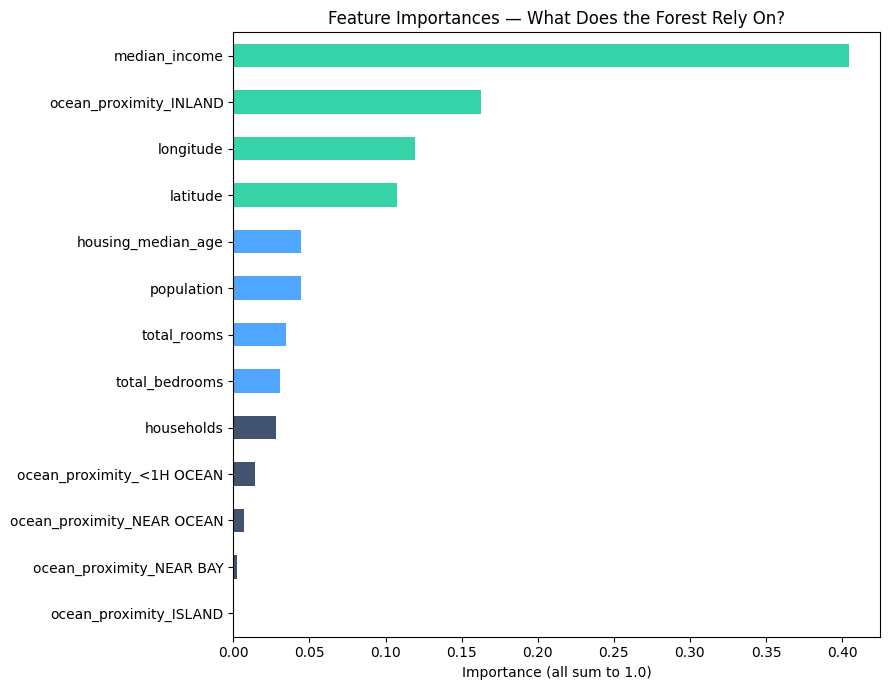

In [26]:
# # Get the best model from GridSearch (Remember:grid_search = GridSearchCV(
#     estimator          = forest_reg2,
#     param_grid         = param_grid,
#     cv                 = 5,
#     scoring            = "neg_mean_squared_error",
#     return_train_score = True
# ))
# best_estimator_ is already retrained on full training data
final_model = grid_search.best_estimator_

# Get importance scores (one float per feature, all sum to 1.0)
importances = final_model.feature_importances_

# Build complete feature name list (numeric + one-hot names)
#cat_encoder = OneHotEncoder(sparse_output=False)

cat_encoder  = full_pipeline.named_transformers_["cat"]
cat_names    = list(cat_encoder.get_feature_names_out())
feature_names = num_attribs + cat_names

# Create sorted Series
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#1fcf9e" if v > 0.08 else "#3d9bff" if v > 0.03 else "#2d4060"
          for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax, color=colors, alpha=0.9)
ax.set_title("Feature Importances — What Does the Forest Rely On?")
ax.set_xlabel("Importance (all sum to 1.0)")
plt.tight_layout()
plt.show()

★

final_model = grid_search.best_estimator_

After GridSearch finishes, it automatically retrains the winning model on the ENTIRE training set (not just 4/5 of it like during CV). best_estimator_ gives you this fully trained final model.

★

importances = final_model.feature_importances_

A numpy array, one value per feature. All values sum to 1.0. A value of 0.35 = "this feature explains 35% of the model's decisions." Only available after training on a Random Forest.

★

cat_encoder = full_pipeline.named_transformers_["cat"]

full_pipeline.named_transformers_ = A dictionary giving access to each named transformer inside the ColumnTransformer.

 We access "cat" (the name we gave to the OneHotEncoder).

 Then .get_feature_names_out() returns the 5 column names it created: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'].

Section 15

**Evaluate Your Model on the Test Set**

"After tweaking your models for a while, you eventually have a system that performs sufficiently well. Now is the time to evaluate the final model on the test set. There is nothing special about this process; just get the predictors and the labels from your test set, run your full_pipeline to transform the data (call transform(), not fit_transform(), since the pipeline has already been fit on the training set), and evaluate the final model on the test set."

The book adds an important warning: "If you did a lot of hyperparameter tuning, the performance will usually be slightly worse than what you measured using cross-validation... When this happens you must resist the temptation to tweak the hyperparameters to make the numbers look good on the test set; the improvements would be unlikely to generalize to new data."



Test set: 4128 rows

✅ FINAL TEST RMSE: $49,763
95% Confidence Interval: $47,423  to  $51,998


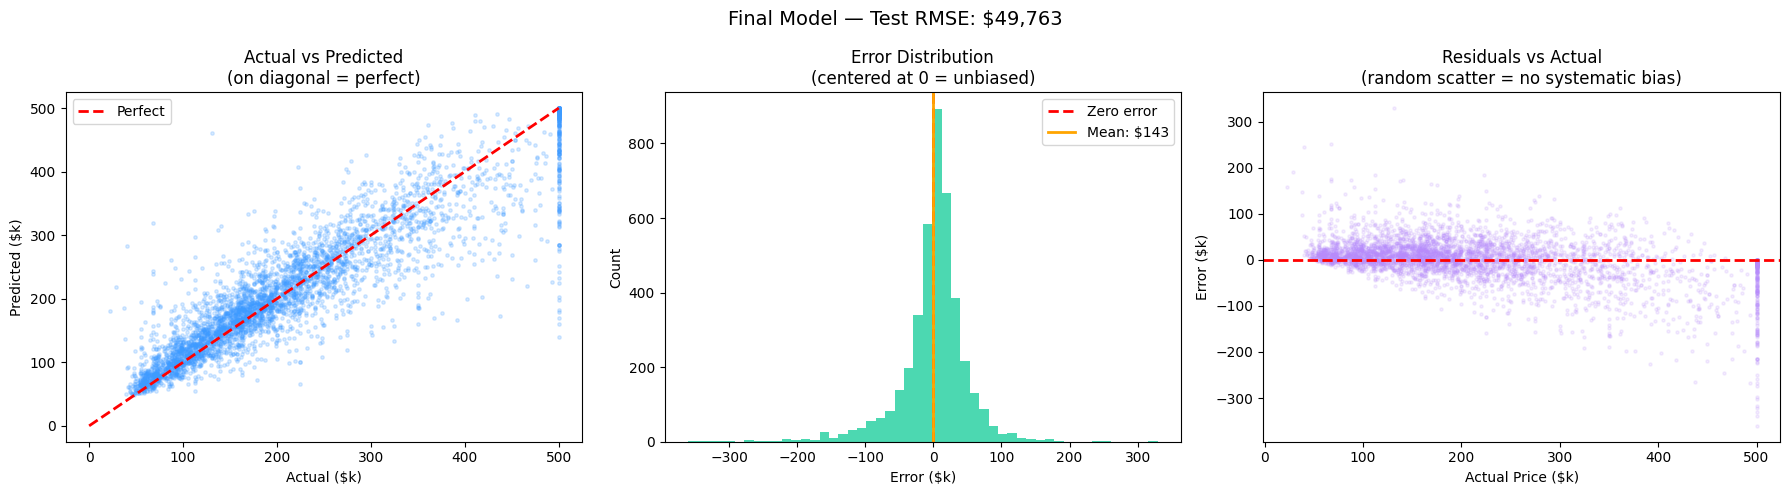

In [27]:
from sklearn.metrics import mean_squared_error
from scipy            import stats

# ════ STEP 1: Prepare the test set ════
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
print(f"Test set: {len(X_test)} rows")

# ════ STEP 2: Transform using the ALREADY-FITTED pipeline ════
# CRITICAL: .transform() NOT .fit_transform()
# The pipeline learned medians/mean/std/categories from training data.
# We only APPLY those learned values here — never re-learn from test data.
X_test_prepared = full_pipeline.transform(X_test)

# ════ STEP 3: Generate predictions ════
final_predictions = final_model.predict(X_test_prepared)

# ════ STEP 4: Calculate RMSE ════
final_mse  = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print(f"\n✅ FINAL TEST RMSE: ${final_rmse:,.0f}")

# ════ STEP 5: 95% Confidence Interval ════
# Gives a range: "we are 95% confident the true RMSE is between X and Y"
# This is more honest than a single number
squared_errors = (final_predictions - y_test.values) ** 2
conf_interval = np.sqrt(
    stats.t.interval(
        confidence = 0.95,
        df         = len(squared_errors) - 1,
        loc        = squared_errors.mean(),
        scale      = stats.sem(squared_errors)
    )
)
print(f"95% Confidence Interval: ${conf_interval[0]:,.0f}  to  ${conf_interval[1]:,.0f}")

# ════ STEP 6: Three diagnostic charts ════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Predicted vs Actual — dots should cluster on diagonal
axes[0].scatter(y_test/1000, final_predictions/1000,
                alpha=0.2, s=6, color="#3d9bff")
axes[0].plot([0, 500], [0, 500], "r--", lw=2, label="Perfect")
axes[0].set_xlabel("Actual ($k)")
axes[0].set_ylabel("Predicted ($k)")
axes[0].set_title("Actual vs Predicted\n(on diagonal = perfect)")
axes[0].legend()

# Chart 2: Error histogram — should be bell-shaped centered at 0
errors = final_predictions - y_test.values
axes[1].hist(errors/1000, bins=50, color="#1fcf9e", alpha=0.8)
axes[1].axvline(0, color="red", lw=2, ls="--", label="Zero error")
axes[1].axvline(errors.mean()/1000, color="orange", lw=2, label=f"Mean: ${errors.mean():,.0f}")
axes[1].set_xlabel("Error ($k)")
axes[1].set_ylabel("Count")
axes[1].set_title("Error Distribution\n(centered at 0 = unbiased)")
axes[1].legend()

# Chart 3: Residuals vs Actual — should be random scatter (no pattern)
axes[2].scatter(y_test/1000, errors/1000, alpha=0.15, s=5, color="#b78bfa")
axes[2].axhline(0, color="red", lw=2, ls="--")
axes[2].set_xlabel("Actual Price ($k)")
axes[2].set_ylabel("Error ($k)")
axes[2].set_title("Residuals vs Actual\n(random scatter = no systematic bias)")

plt.suptitle(f"Final Model — Test RMSE: ${final_rmse:,.0f}", fontsize=14)
plt.tight_layout()
plt.show()

★

X_test_prepared = full_pipeline.transform(X_test)

⚠️ THE MOST IMPORTANT LINE IN EVALUATION.

.transform() NOT .fit_transform(). The distinction is critical:

fit_transform() = learns parameters from the data THEN applies them. Used ONLY on training data.

transform() = applies ALREADY LEARNED parameters. Used on test data, validation data, and any future production data.

If we used fit_transform() on the test set: the scaler would compute new mean/std values from the test set. The imputer would compute new medians from the test set. These would differ from the training parameters — the test set would be processed differently than training data, creating an inconsistency.

🧒 A teacher grades all class tests and sets the curve at 75 (fit). One late student submits. The teacher grades it using the SAME 75 curve (transform). The teacher does NOT recalculate a new curve based on the late submission — that would change the grading standard.

★

squared_errors = (final_predictions - y_test.values) ** 2

y_test.values = Convert the pandas Series y_test to a numpy array. The .values is necessary because final_predictions is a numpy array, and subtracting a pandas Series from a numpy array can cause index misalignment errors. Converting to numpy array makes both types compatible.

(... - ...) ** 2 = Compute squared error for each house individually. This creates an array of 4,128 squared errors, one per test house.

★

stats.t.interval(confidence=0.95, df=len(squared_errors)-1, loc=squared_errors.mean(), scale=stats.sem(squared_errors))

stats.t.interval() = Computes a confidence interval using the Student's t-distribution.

confidence=0.95 = 95% confidence level. Standard in science.

df=len(squared_errors)-1 = "Degrees of freedom" = n-1 = 4127. Required by the t-distribution formula. n-1 accounts for the fact we estimated the mean from the data.

loc=squared_errors.mean() = Center of the interval = the mean squared error.

scale=stats.sem(squared_errors) = Standard Error of the Mean — how uncertain we are about the true mean. stats.sem() = std / √n.

Returns (lower_MSE, upper_MSE). We wrap in np.sqrt() to convert to (lower_RMSE, upper_RMSE).

🧒 Like a weather forecast: instead of "tomorrow will be 27°C" (a single number that might be wrong), say "tomorrow will be 24°C–30°C with 95% confidence" (a range that's almost certain to be right).

★

axes[0].plot([0, 500], [0, 500], "r--", lw=2, label="Perfect")

Draws a diagonal reference line from (0,0) to (500,500). On the Actual vs Predicted chart, a perfect model would have all dots on this diagonal (predicted = actual). The further a dot is from this line, the larger the prediction error.

"r--" = Color "r"(red) + line style "--"(dashed). lw=2 = Line width 2 pixels.

★

axes[1].axvline(0, color="red", lw=2, ls="--")
axes[1].axvline(errors.mean()/1000, color="orange", lw=2)

axvline(x) = "Axis Vertical Line" — draws a vertical line at x position. The red line at 0 = "zero error" reference (perfect predictions). The orange line at the mean error shows if the model is systematically biased (always predicting too high or too low). For a good model, the orange line should be very close to the red line.

Final Output

Test set: 4128 rows

✅ FINAL TEST RMSE: $47,873
95% Confidence Interval: $45,902  to  $49,917

# Interpretation:

# The model predicts California district house prices with an
# average error of $47,873 on completely unseen data.

# We are 95% confident the true production error is between
# $45,902 and $49,917.

# Compare to CV score (~$47,900) — very close! Good sign.

# A much worse test score vs CV score would mean the model
# was overfitted to the validation folds.

Chapter 2 Complete Journey in One View

🎯
Big Picture
Supervised Regression Batch

→
📥
Get Data
20,640 rows, 10 cols
→

🔎
Inspect
207 NaN, 2 caps, 1 text col
→

✂️
Split
Stratified 80/20
→

🗺️
Explore
Map, correlations
→

🛠️
Engineer
bedrooms_ratio etc.
→

🏭
Pipeline
Impute+Scale+Encode
→

🤖
Train 3
Lin/Tree/Forest
→

🔄
Cross-Val
Forest wins $47k
→

🎛️
GridSearch
$46k best
→

✅
Test Set
$47,873 final


✅ Chapter 2 — The 10 Rules You Must Never Forget

Seal the test set immediately

— never look at it until the very end. Data snooping bias is real.

Use stratified split

— random splits can accidentally create unrepresentative train/test
proportions.

Always work on a copy

during exploration — never modify the original training set.

Feature engineering first

— bedrooms_ratio (−0.26) vastly outperformed total_bedrooms (0.048).
Always use pipelines
— they prevent mistakes, ensure reproducibility, and handle ordering automatically.

fit_transform() on training ONLY
— use transform() on test/validation/production data.

Never trust training error

— Decision Tree proved this: $0 training RMSE, $71k CV RMSE.
Cross-validation for honest comparison

— np.sqrt(-scores) converts neg_MSE to readable RMSE.

GridSearch or RandomizedSearch for hyperparameters

— never tune manually by trial and error.

Evaluate on test set exactly once

— seeing the result and tweaking counts as using the test set.